## 📊 Feature Engineering — AMZN Stock Forecasting

We create **technical indicators** from raw price data.

These features will be used as **inputs to the forecasting model**.

⚠️ **Important:**  
All features are derived **only from past data** to avoid *lookahead bias*  
—a critical rule in financial modelling.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Load and clean data (same as EDA notebook)
df = pd.read_csv('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/data/sp500_stocks.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['date'] = pd.to_datetime(df['date'])
df_clean = df.dropna(subset=['close']).copy()

# Filter to AMZN only
amzn = df_clean[df_clean['symbol'] == 'AMZN'].sort_values('date').reset_index(drop=True)

print(f"AMZN rows: {len(amzn)}")
print(f"Date range: {amzn['date'].min().date()} to {amzn['date'].max().date()}")
amzn[['date','open','high','low','close','volume']].head()

AMZN rows: 3768
Date range: 2010-01-04 to 2024-12-20


,date,open,high,low,close,volume
0,2010-01-04,6.8125,6.8305,6.6570,6.6950,151998000.0
1,2010-01-05,6.6715,6.7740,6.5905,6.7345,177038000.0
2,2010-01-06,6.7300,6.7365,6.5825,6.6125,143576000.0
3,2010-01-07,6.6005,6.6160,6.4400,6.5000,220604000.0
4,2010-01-08,6.5280,6.6840,6.4515,6.6760,196610000.0


## 1. Moving Averages 
A moving average smooths out daily noise to reveal the underlying trend. We create three: - **MA7** — 7-day (short term, reacts quickly) - **MA21** — 21-day (medium term, ~1 trading month) - **MA50** — 50-day (long term trend signal) When a short MA crosses above a long MA it is often interpreted as a bullish signal — this is called a "golden cross" in trading.

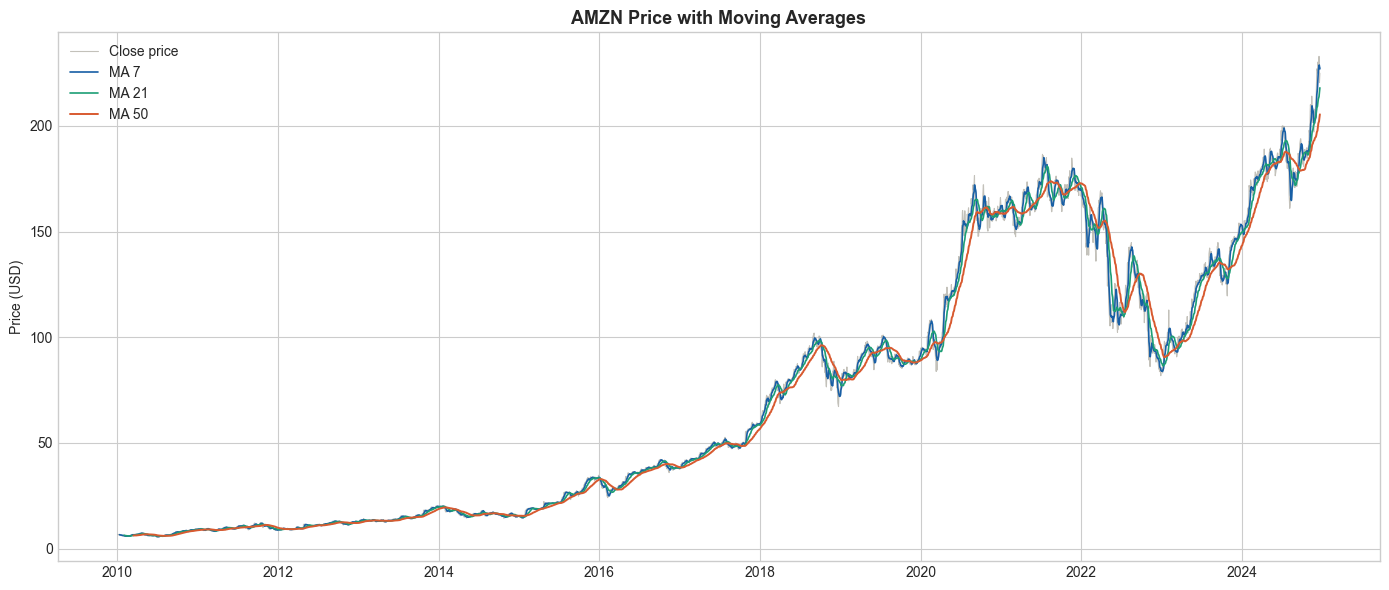

Saved to outputs/


In [5]:
amzn['ma7']  = amzn['close'].rolling(window=7).mean()
amzn['ma21'] = amzn['close'].rolling(window=21).mean()
amzn['ma50'] = amzn['close'].rolling(window=50).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(amzn['date'], amzn['close'], color='#B4B2A9', linewidth=0.8,
        alpha=0.8, label='Close price')
ax.plot(amzn['date'], amzn['ma7'],  color='#185FA5', linewidth=1.2, label='MA 7')
ax.plot(amzn['date'], amzn['ma21'], color='#1D9E75', linewidth=1.2, label='MA 21')
ax.plot(amzn['date'], amzn['ma50'], color='#D85A30', linewidth=1.4, label='MA 50')

ax.set_title('AMZN Price with Moving Averages', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/amzn_moving_averages.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

## 2. RSI 
Relative Strength Index RSI measures momentum — whether a stock is being overbought or oversold. It ranges from 0 to 100: - Above 70 = overbought (price may drop soon) - Below 30 = oversold (price may rise soon) - Around 50 = neutral momentum RSI is one of the most widely used indicators in quantitative finance and trading systems.

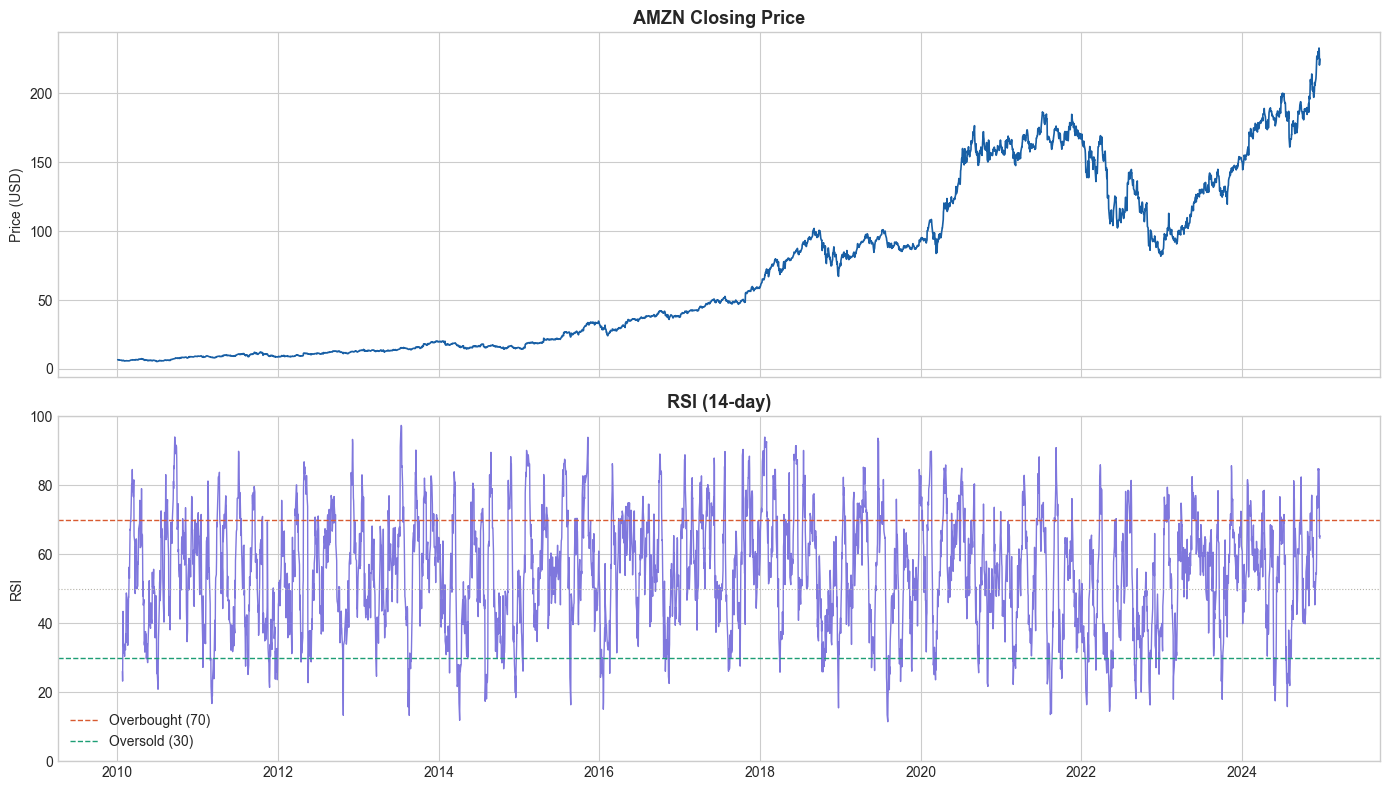

In [6]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

amzn['rsi14'] = calculate_rsi(amzn['close'], period=14)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(amzn['date'], amzn['close'], color='#185FA5', linewidth=1.2)
axes[0].set_title('AMZN Closing Price', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(amzn['date'], amzn['rsi14'], color='#7F77DD', linewidth=1.0)
axes[1].axhline(70, color='#D85A30', linestyle='--', linewidth=1, label='Overbought (70)')
axes[1].axhline(30, color='#1D9E75', linestyle='--', linewidth=1, label='Oversold (30)')
axes[1].axhline(50, color='#B4B2A9', linestyle=':', linewidth=0.8)
axes[1].set_title('RSI (14-day)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/amzn_rsi.png',
            dpi=120, bbox_inches='tight')
plt.show()

## 3. Volatility and Lag Features
Volatility measures how much the price moves day to day. Lag features give the model memory — yesterday's price, the price 5 days ago etc. These are essential for any time series forecasting model.


In [7]:
# Daily return
amzn['daily_return'] = amzn['close'].pct_change()

# Rolling volatility (std of returns over 21 days)
amzn['volatility21'] = amzn['daily_return'].rolling(window=21).std()

# Lag features — previous closing prices
amzn['lag1'] = amzn['close'].shift(1)   # yesterday
amzn['lag5'] = amzn['close'].shift(5)   # 5 days ago
amzn['lag21'] = amzn['close'].shift(21) # 21 days ago

# Price momentum — how much has price changed over N days
amzn['momentum5']  = amzn['close'] - amzn['close'].shift(5)
amzn['momentum21'] = amzn['close'] - amzn['close'].shift(21)

# Volume change
amzn['volume_change'] = amzn['volume'].pct_change()

print("Features created:")
feature_cols = ['ma7','ma21','ma50','rsi14','volatility21',
                'lag1','lag5','lag21','momentum5','momentum21','volume_change']
print(feature_cols)
print(f"\nSample of feature data:")
amzn[['date','close'] + feature_cols].dropna().head()

Features created:
['ma7', 'ma21', 'ma50', 'rsi14', 'volatility21', 'lag1', 'lag5', 'lag21', 'momentum5', 'momentum21', 'volume_change']

Sample of feature data:


,date,close,ma7,ma21,ma50,rsi14,volatility21,lag1,lag5,lag21,momentum5,momentum21,volume_change
49,2010-03-16,6.5895,6.555429,6.219452,6.21460,76.715358,0.016165,6.5565,6.4410,5.9830,0.1485,0.6065,-0.347074
50,2010-03-17,6.5670,6.564214,6.252333,6.21204,80.529750,0.015451,6.5895,6.5255,5.8765,0.0415,0.6905,0.054761
51,2010-03-18,6.6380,6.592357,6.291500,6.21011,81.574326,0.015055,6.5670,6.6790,5.8155,-0.0410,0.8225,0.151991
52,2010-03-19,6.5175,6.591214,6.320714,6.20821,65.281422,0.015822,6.6380,6.5910,5.9040,-0.0735,0.6135,0.773445
53,2010-03-22,6.5235,6.569000,6.351548,6.20868,63.616309,0.015699,6.5175,6.5565,5.8760,-0.0330,0.6475,-0.395463


## 4. Target Variable and Train/Test Split

Our target is tomorrow's closing price — we want to predict one day ahead. We use an 80/20 time-based split: - Train: first 80% of dates (model learns from this) - Test: last 20% of dates (we evaluate on this) Important: we never shuffle the data. Time series data must stay in chronological order — shuffling would leak future data into training, making results meaningless.

Rows available for modelling: 3718

Train set: 2974 rows (2010-03-16 to 2022-01-04)
Test set:  744 rows (2022-01-05 to 2024-12-19)


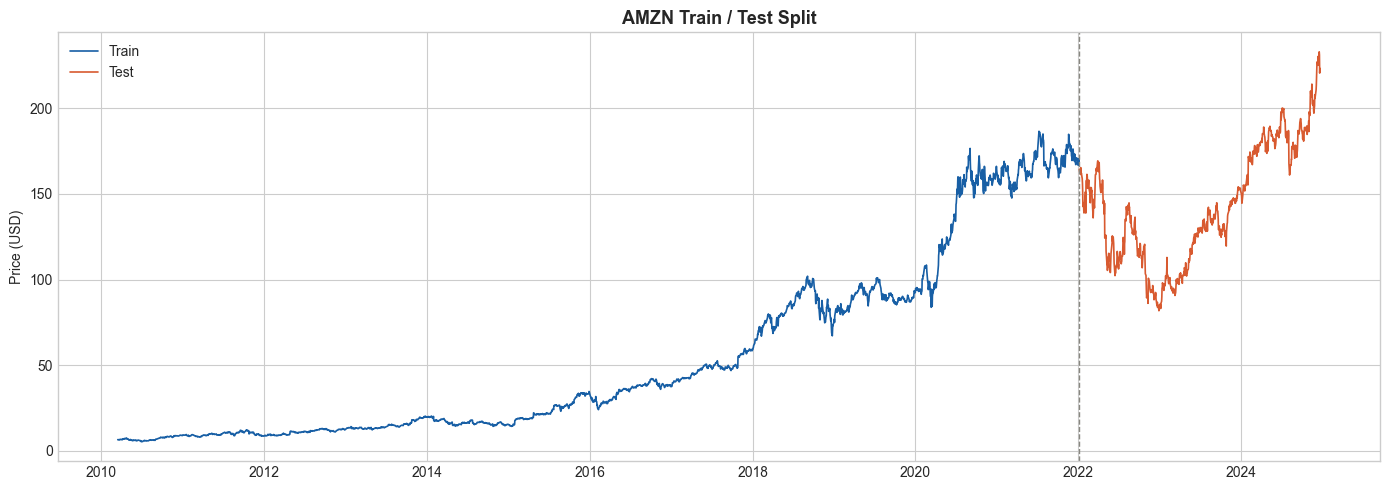


Saved to outputs/


In [8]:
# Target: next day's closing price
amzn['target'] = amzn['close'].shift(-1)

# Drop rows with any NaN (from rolling windows and shifts)
feature_cols = ['ma7','ma21','ma50','rsi14','volatility21',
                'lag1','lag5','lag21','momentum5','momentum21',
                'volume_change']

amzn_model = amzn[['date','close','target'] + feature_cols].dropna().copy()

print(f"Rows available for modelling: {len(amzn_model)}")

# 80/20 time-based split
split_idx = int(len(amzn_model) * 0.8)
train = amzn_model.iloc[:split_idx]
test  = amzn_model.iloc[split_idx:]

print(f"\nTrain set: {len(train)} rows ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test set:  {len(test)} rows ({test['date'].min().date()} to {test['date'].max().date()})")

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train['date'], train['close'], color='#185FA5', linewidth=1.2, label='Train')
ax.plot(test['date'],  test['close'],  color='#D85A30', linewidth=1.2, label='Test')
ax.axvline(train['date'].iloc[-1], color='#888780', linestyle='--', linewidth=1)
ax.set_title('AMZN Train / Test Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/train_test_split.png',
            dpi=120, bbox_inches='tight')
plt.show()

print("\nSaved to outputs/")

## 5. Save Engineered Dataset
We save the processed dataset so the modelling notebook can load it directly without repeating all this work.


In [10]:
save_path = 'C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/data/amzn_features.csv'
amzn_model.to_csv(save_path, index=False)

print(f"Saved engineered dataset to: data/amzn_features.csv")
print(f"Shape: {amzn_model.shape}")
print(f"\nFinal feature list:")
for col in feature_cols:
    print(f"  {col}")

Saved engineered dataset to: data/amzn_features.csv
Shape: (3718, 14)

Final feature list:
  ma7
  ma21
  ma50
  rsi14
  volatility21
  lag1
  lag5
  lag21
  momentum5
  momentum21
  volume_change


## Summary 
We engineered 11 features from raw AMZN price data: - 3 moving averages (MA7, MA21, MA50) to capture trend - RSI to capture momentum - 21-day rolling volatility - 3 lag features (1, 5, 21 days) to give the model memory - 2 momentum features (5 and 21 day) - Volume change The dataset was split 80/20 on a time basis, giving [X] training rows and [X] test rows. No data leakage was introduced — all features use only past information.